# Solve 5 seeds per point cloud size and investigate solving duration

In [1]:
import sys
sys.path.insert(0, '../src')

import matplotlib.pyplot as plt
import numpy as np

from typing import Any
from feature_extractor import GeometricFeatureExtractor
from icp import ICP, MultiStartICP
from experiment_runner import MultiSeedSyntheticICPResult, fit_multi_seed
from matcher import NearestNeighborMatcher
from visualization import ErrorMetricsVisualizer

plt.style.use('seaborn-v0_8-whitegrid')

MAX_ITER = 200
N_SEEDS = 5
N_STARTS = 13

In [2]:
extractor = GeometricFeatureExtractor(k=4)
nn_matcher = NearestNeighborMatcher(feature_extractor=extractor)
nn_single_icp = ICP(matcher=nn_matcher, max_iter=MAX_ITER)
nn_icp = MultiStartICP(nn_single_icp, n_starts=N_STARTS)

In [3]:
seeds = list(range(N_SEEDS))
n_points = [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500]

results: list[MultiSeedSyntheticICPResult] = []
for n in n_points:
    experiment_kwargs: dict[str, Any] = {'n': n, 'noise_std': 0.01, 't_scale': 8, 'style': 'clustered'}
    result = fit_multi_seed(nn_icp, experiment_kwargs=experiment_kwargs, seeds=seeds)
    results.append(result)

Solving 5 seeds: 100%|██████████| 5/5 [01:19<00:00, 15.91s/it]


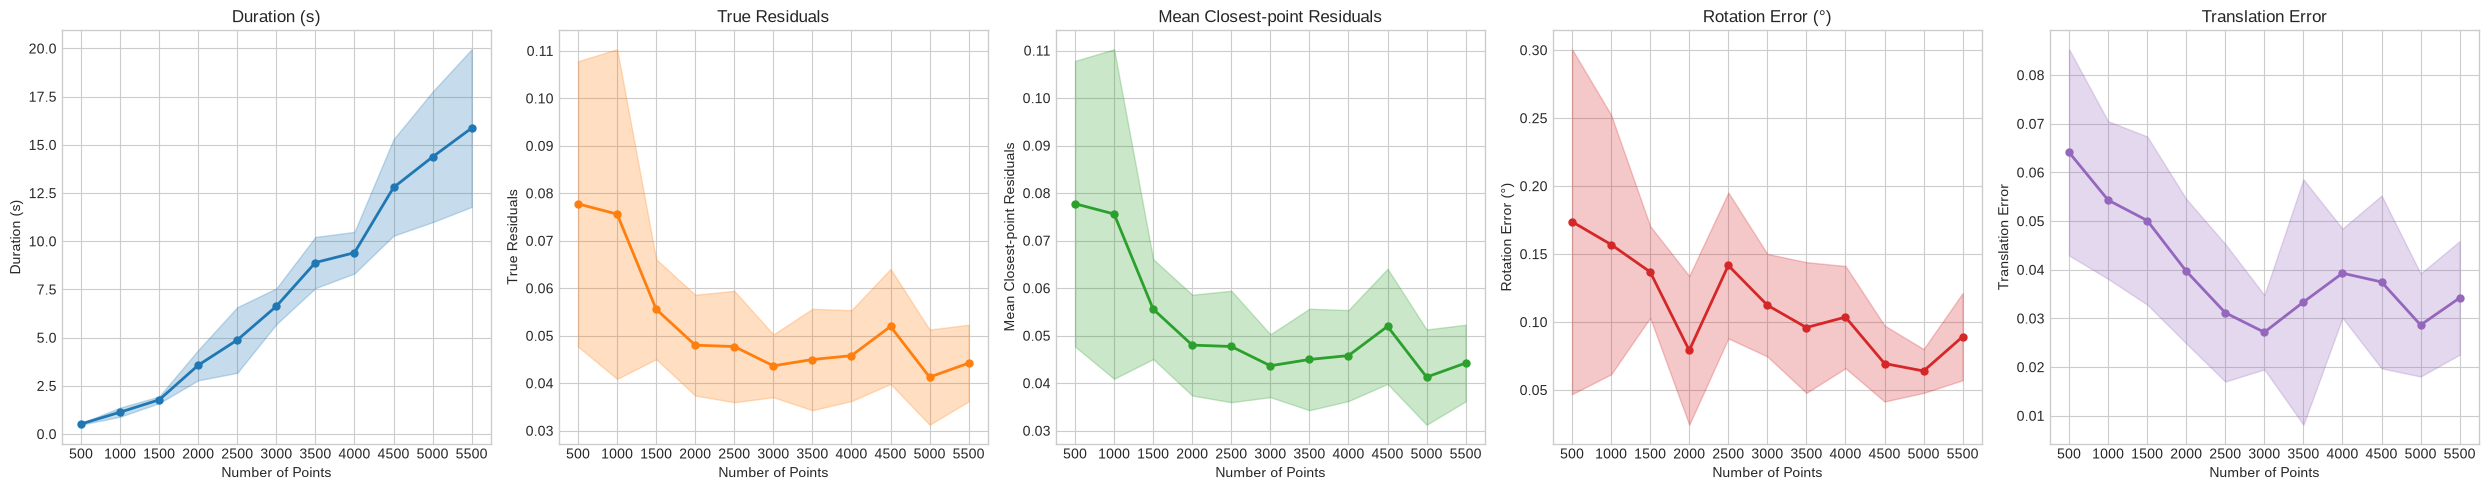

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
ErrorMetricsVisualizer.plot_parameter_sweep(
    axes=axes,
    data_per_metric=[np.array([result.durations_s for result in results]), np.array([result.mean_true_residuals for result in results]), np.array([result.mean_closest_point_residuals for result in results]), np.array([result.rotation_errors for result in results]), np.array([result.translation_errors for result in results])],
    y_labels=['Duration (s)', 'True Residuals', 'Mean Closest-point Residuals', 'Rotation Error (°)', 'Translation Error'],
    x_label='Number of Points',
    x = n_points
)
plt.tight_layout()
plt.savefig('../results/9_scaling_rainbow.png', dpi=300)
plt.show()